In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator

import sys
from pathlib import Path

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))


from utils.dataset import DataSet
from tda.grids import DataSetGrid, Grid3D, GridActivity, get_ranges_from_positions

import matplotlib.pyplot as plt


In [ ]:
# path to the folder with the data as downloaded
folder_data = repo_root / 'data/'

# path to the metadata folder
folder_meta = repo_root / 'metadata'

# path to the derivatives folder
folder_derivatives = repo_root / 'derivatives' / 'grid-15x15x10_normalization-by_minmax'

#recordings to use
recordings_to_use = [
    # 'dynamic29156-11-10-Video-8744edeac3b4d1ce16b680916b5267ce',
    # 'dynamic29228-2-10-Video-8744edeac3b4d1ce16b680916b5267ce',
    # 'dynamic29234-6-9-Video-8744edeac3b4d1ce16b680916b5267ce',
    'dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce',
    # 'dynamic29514-2-9-Video-8744edeac3b4d1ce16b680916b5267ce',
    # 'dynamic29712-5-9-Video-9b4f6a1a067fe51e15306b9628efea20',
    # 'dynamic29515-10-12-Video-9b4f6a1a067fe51e15306b9628efea20',
    # 'dynamic29623-4-9-Video-9b4f6a1a067fe51e15306b9628efea20',
    # 'dynamic29647-19-8-Video-9b4f6a1a067fe51e15306b9628efea20',
    # 'dynamic29755-2-8-Video-9b4f6a1a067fe51e15306b9628efea20',
   ]


In [3]:
# initialize the object to handle the dataset
ds = DataSetGrid(folder_data, 
             folder_metadata=folder_meta, 
             folder_derivatives=folder_derivatives,
             recording=recordings_to_use, 
             check=False,
             verbose=True)

# load a dataframe with all trials metadata
trials_df =ds.get_trials_metadata()


Initializing DataSet -------------------------------------------------------------------------------

Data integrity check skipped -----------------------------------------------------------------------
 > If you want to check it, set check and check_data to True when initializing the DataSet.
 > Data is assumed to be valid. Misbehavior may occur if the data is corrupted.

Metadata integrity check skipped -------------------------------------------------------------------
 > If you want to check it, set check and check_metadata to True when initializing the DataSet.
 > Metadata will be assumed to be valid for existing folders and invalid for missing folders.

Loading neurons metadata ---------------------------------------------------------------------------
 > Loading neurons for recording dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce from metadata

Creating basic trials metadata DataFrame from data -------------------------------------------------

Creating trials metadata

In [4]:
stats =ds.compute_grid_stats(recordings_to_use[0])

Could not load grid activity for trial 303: [Errno 2] No such file or directory: '/home/anaflo/Documenti/MDMC/sensorium/derivatives/grid-15x15x10_normalization-by_minmax/dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce/trials/303.npy'
Could not load grid activity for trial 664: [Errno 2] No such file or directory: '/home/anaflo/Documenti/MDMC/sensorium/derivatives/grid-15x15x10_normalization-by_minmax/dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce/trials/664.npy'
Could not load grid activity for trial 389: [Errno 2] No such file or directory: '/home/anaflo/Documenti/MDMC/sensorium/derivatives/grid-15x15x10_normalization-by_minmax/dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce/trials/389.npy'
Could not load grid activity for trial 91: [Errno 2] No such file or directory: '/home/anaflo/Documenti/MDMC/sensorium/derivatives/grid-15x15x10_normalization-by_minmax/dynamic29513-3-5-Video-8744edeac3b4d1ce16b680916b5267ce/trials/91.npy'
Could not load grid activity for t

In [7]:
stats['trials_in_stats']

['321',
 '147',
 '261',
 '619',
 '285',
 '704',
 '400',
 '550',
 '464',
 '383',
 '433',
 '646',
 '301',
 '167']

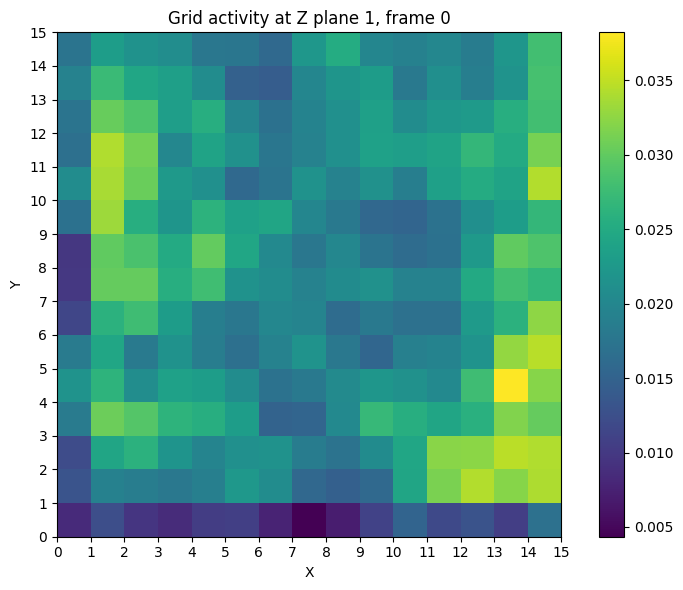

Text(0.5, 1.0, 'Mean activation across trials')

In [ ]:
grid = ds.info[recordings_to_use[0]]['grid']
grid.plot_colormesh_grid_activity(2, 1, 0, stats['mean_activation'][:,:,:,np.newaxis])

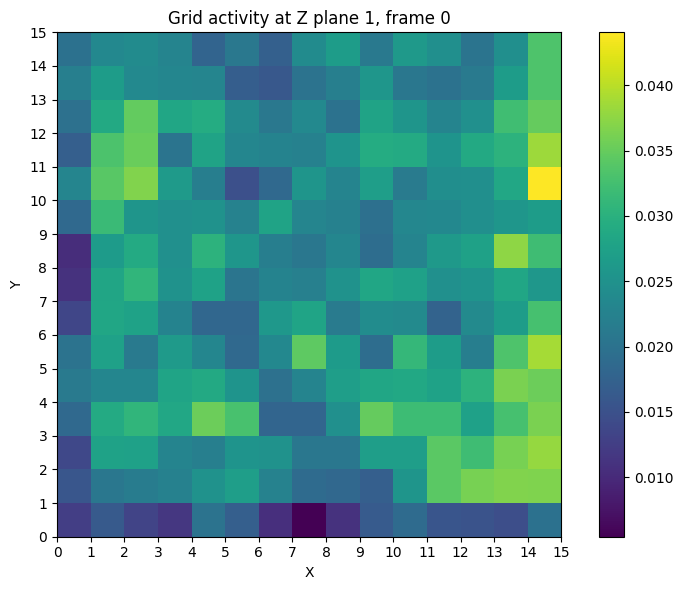

<Axes: title={'center': 'Grid activity at Z plane 1, frame 0'}, xlabel='X', ylabel='Y'>

In [16]:
grid = ds.info[recordings_to_use[0]]['grid']
grid.plot_colormesh_grid_activity(2, 1, 0, stats['std_activation'][:,:,:,np.newaxis])

In [13]:
ax

<Axes: title={'center': 'Mean activation across trials'}, xlabel='X', ylabel='Y'>

In [18]:
grid_activity = ds.load_gridactivity_by_trial(recording=recordings_to_use[0], trial='147')
responses = ds.load_response_by_trial(recording=recordings_to_use[0], trial='147')

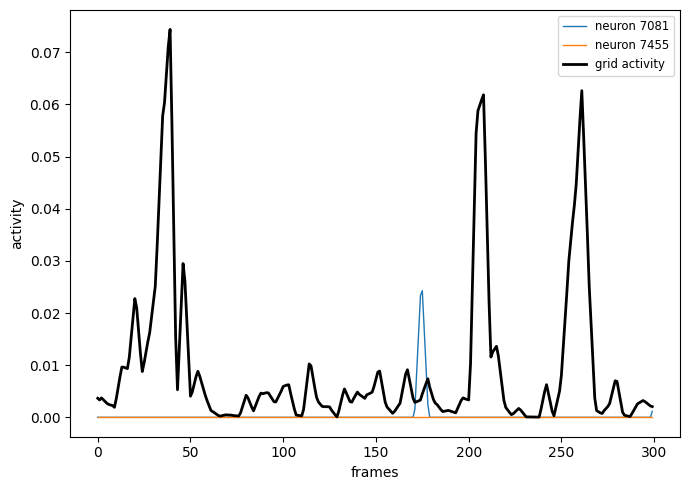

In [5]:
grid_activity.plot_activity_in_cell(cell_idx=(10,5,3), positions=responses.neurons.coord_xyz, activities=responses.get_data(normalization="by_minmax"), normalization=None)

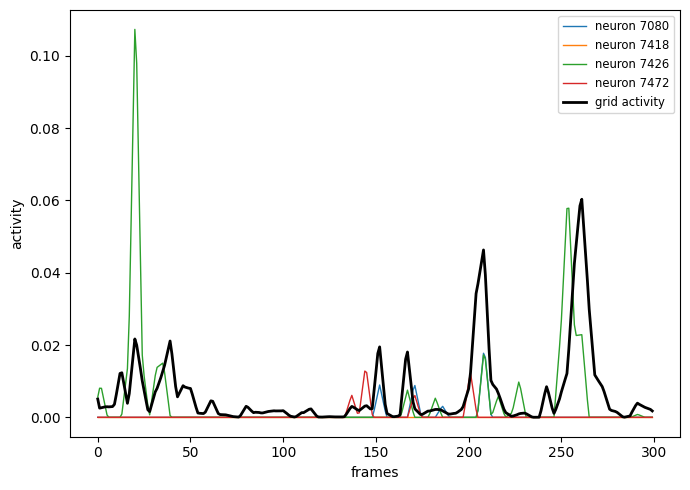

In [6]:
grid_activity.plot_activity_in_cell(cell_idx=(9,5,3), positions=responses.neurons.coord_xyz, activities=responses.get_data(normalization="by_minmax"), normalization=None)

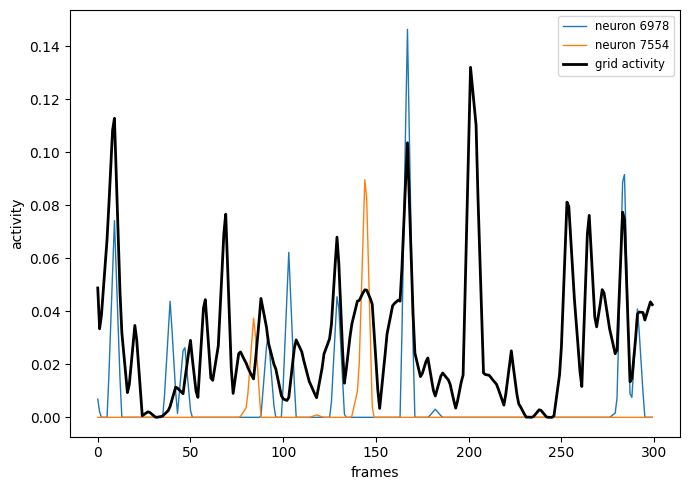

In [7]:
grid_activity.plot_activity_in_cell(cell_idx=(14,1,3), positions=responses.neurons.coord_xyz, activities=responses.get_data(normalization="by_minmax"), normalization=None)

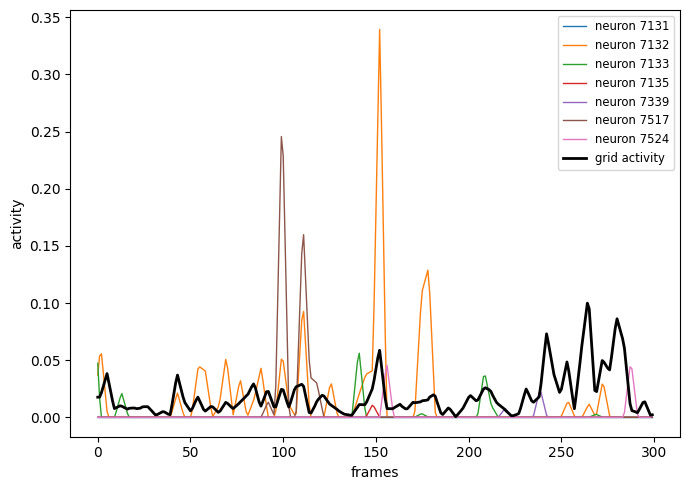

In [19]:
grid_activity.plot_activity_in_cell(cell_idx=(6,7,3), positions=responses.neurons.coord_xyz, activities=responses.get_data(normalization="by_minmax"), normalization=None)

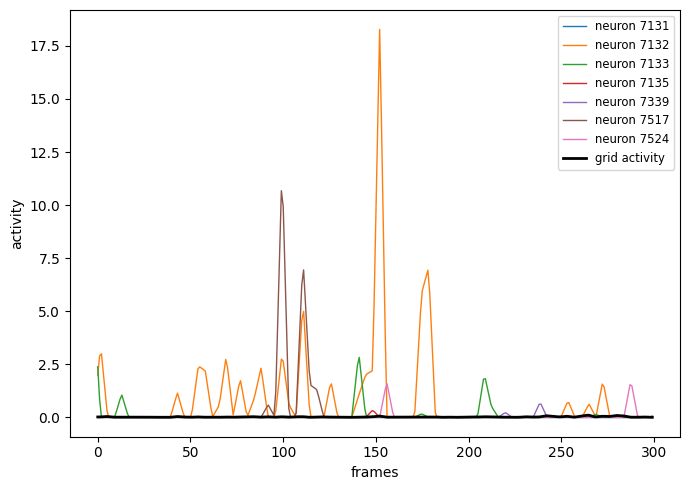

In [21]:
grid_activity.plot_activity_in_cell(cell_idx=(6,7,3), positions=responses.neurons.coord_xyz, activities=responses.get_data(normalization="by_std"), normalization=None)

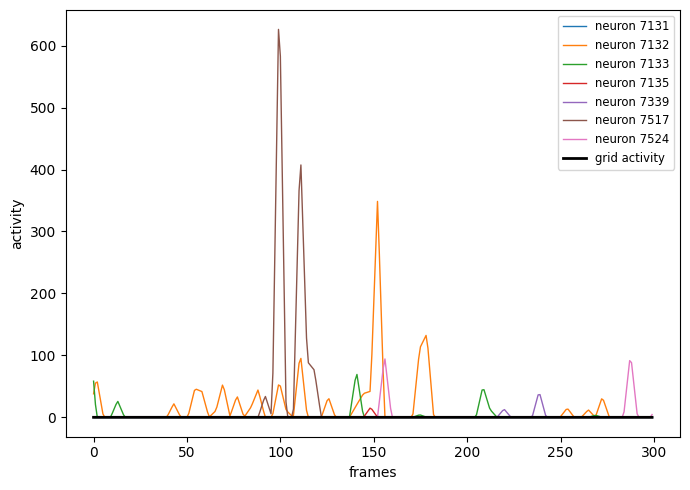

In [20]:
grid_activity.plot_activity_in_cell(cell_idx=(6,7,3), positions=responses.neurons.coord_xyz, activities=responses.get_data(normalization=None), normalization=None)

/home/anaflo/Documenti/MDMC/sensorium/tda/grids.py:183: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


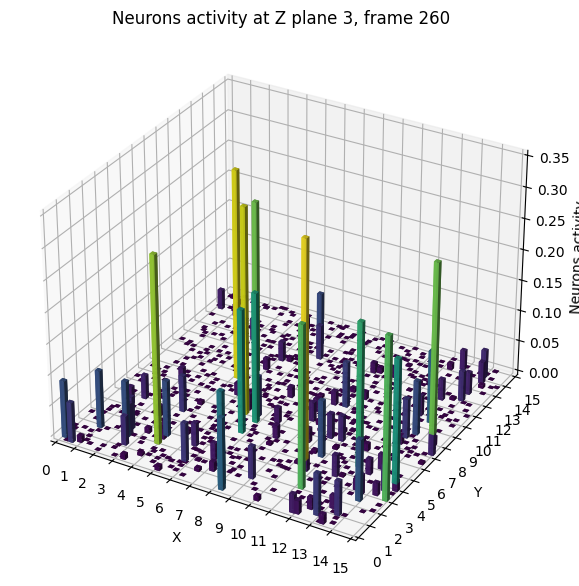

<Axes3D: title={'center': 'Neurons activity at Z plane 3, frame 260'}, xlabel='X', ylabel='Y', zlabel='Neurons activity'>

In [6]:
grid_activity.grid.plot_bar_neurons_activity(axis=2, plane_idx=3, frame=260, positions=responses.neurons.coord_xyz, activities=responses.get_data(normalization="by_minmax"))

In [5]:
grid_activity.grid.xyz_ranges

array([[-1408. ,  -792. ],
       [ -685. ,   -67. ],
       [  187.5,   437.5]])

In [6]:
x_coord = 0
y_coord = 0
z_coord = 0
print(f"x = {grid_activity.grid.xyz_coordinates[0][x_coord,y_coord,z_coord]}")
print(f"y = {grid_activity.grid.xyz_coordinates[1][x_coord,y_coord,z_coord]}")
print(f"z = {grid_activity.grid.xyz_coordinates[2][x_coord,y_coord,z_coord]}")

x = -1387.4666666666667
y = -664.4
z = 200.0


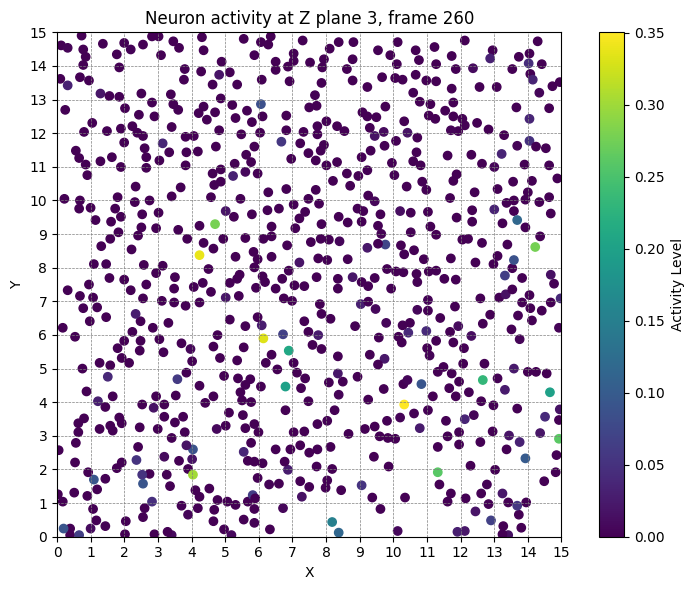

<Axes: title={'center': 'Neuron activity at Z plane 3, frame 260'}, xlabel='X', ylabel='Y'>

In [6]:
grid_activity.grid.plot_scatter_neurons_activity(axis=2, plane_idx=3, frame=260, positions=responses.neurons.coord_xyz, activities=responses.get_data(normalization="by_minmax"))

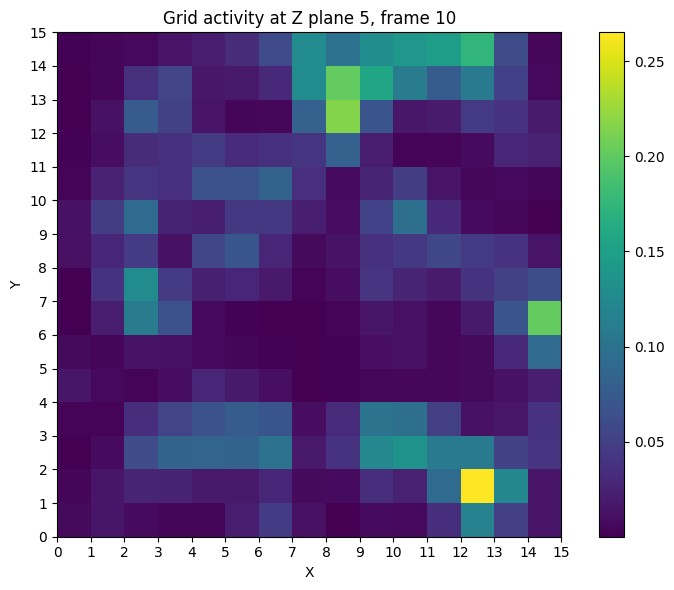

In [10]:
grid_activity.plot_colormesh(2, 5, 10)

/home/anaflo/Documenti/MDMC/sensorium/tda/grids.py:242: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


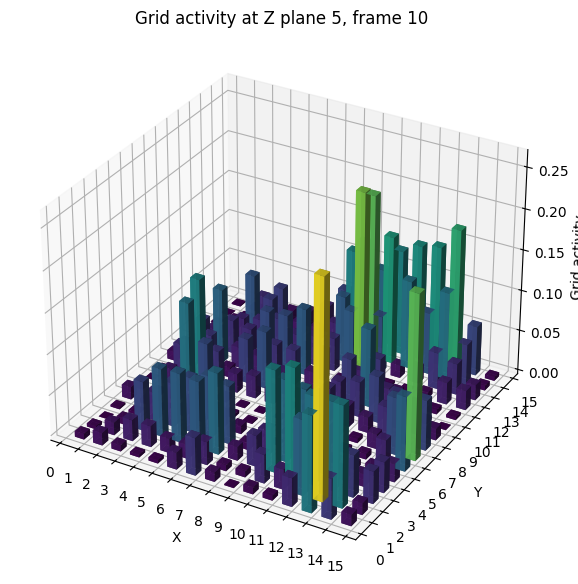

In [5]:
grid_activity.plot_bar(2, 5, 10)

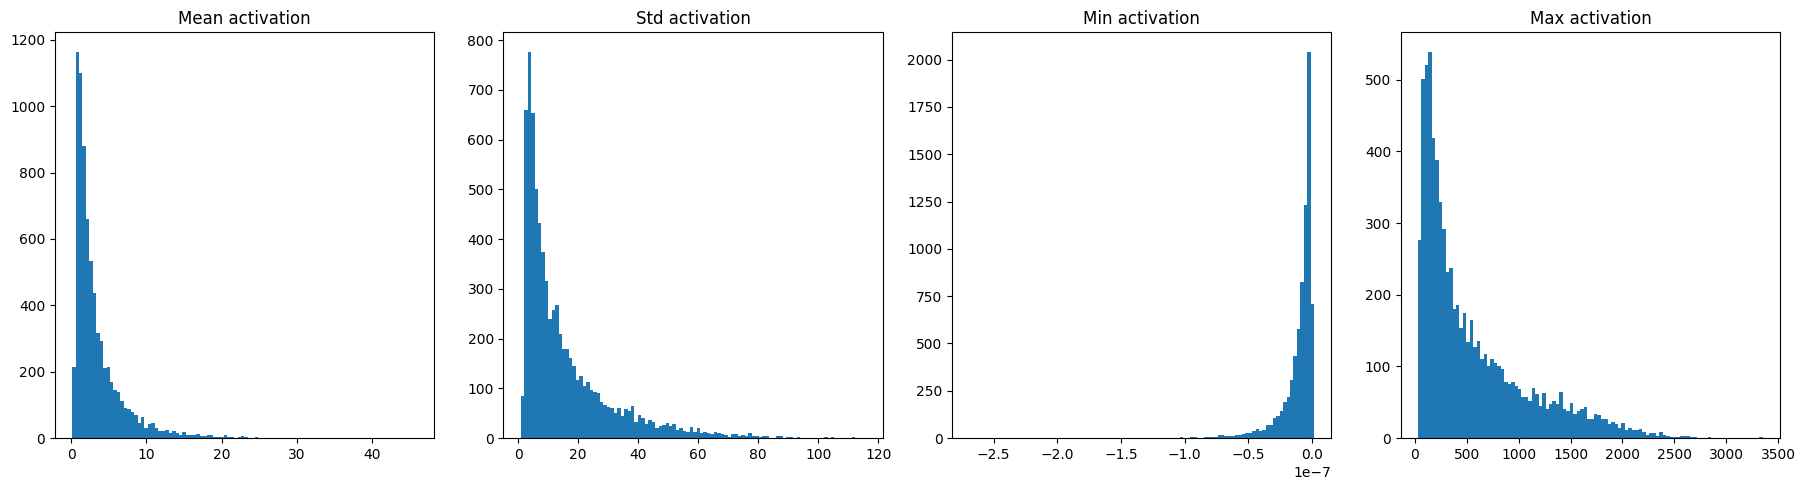

In [4]:
fig, ax = plt.subplots(1, 4, figsize=(18, 5))
_ = ax[0].hist(ds.info[ds.recording[0]]["neurons"].stats_activity['mean_activation'], bins=100)
ax[0].set_title('Mean activation')
_ = ax[1].hist(ds.info[ds.recording[0]]["neurons"].stats_activity['std_activation'], bins=100)
ax[1].set_title('Std activation')
_ = ax[2].hist(ds.info[ds.recording[0]]["neurons"].stats_activity['min_activation'], bins=100)
ax[2].set_title('Min activation')
_ = ax[3].hist(ds.info[ds.recording[0]]["neurons"].stats_activity['max_activation'], bins=100)
ax[3].set_title('Max activation')
plt.tight_layout()

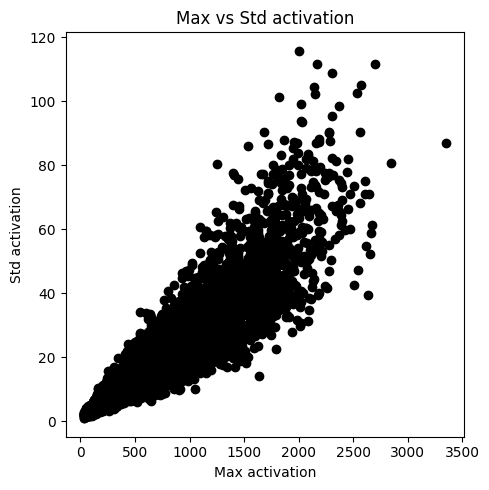

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.plot(ds.info[ds.recording[0]]["neurons"].stats_activity['max_activation'], ds.info[ds.recording[0]]["neurons"].stats_activity['std_activation'], 'ok')
ax.set_xlabel('Max activation')
ax.set_ylabel('Std activation')
ax.set_title('Max vs Std activation')
plt.tight_layout()


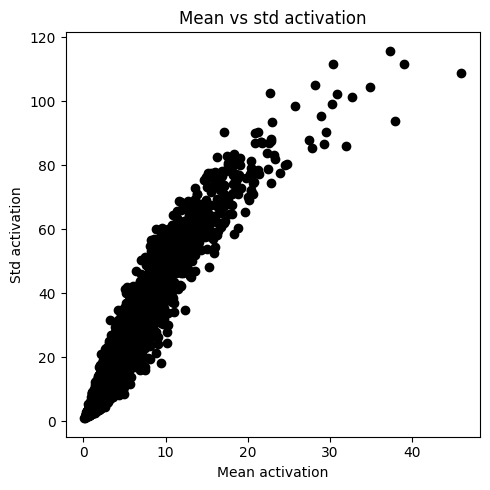

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.plot(ds.info[ds.recording[0]]["neurons"].stats_activity['mean_activation'], ds.info[ds.recording[0]]["neurons"].stats_activity['std_activation'], 'ok')
ax.set_xlabel('Mean activation')
ax.set_ylabel('Std activation')
ax.set_title('Mean vs std activation')
plt.tight_layout()

In [7]:
num_grid=(15, 15, 10)
positions = ds.info[ds.recording[0]]["neurons"].coord_xyz
xyz_ranges = get_ranges_from_positions(positions)
grid = Grid3D(xyz_ranges, num_grid)

response = ds.load_response_by_trial(recording=ds.recording[0], trial='0')

# grid activity without previous normalization
activities = response.get_data()
grid_activity  = grid.compute_grid_activity(positions, activities)

# grid activity with minmax normalization
activities_minmax = response.get_data(normalization='by_minmax')
grid_activity_minmax = grid.compute_grid_activity(positions, activities_minmax)

# grid activity with std normalization
activities_std = response.get_data(normalization='by_std')
grid_activity_std = grid.compute_grid_activity(positions, activities_std)


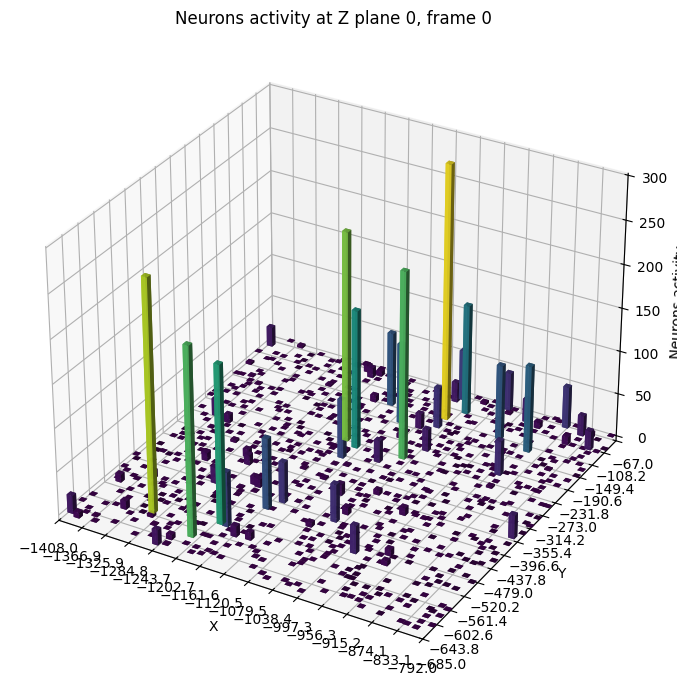

<Axes3D: title={'center': 'Neurons activity at Z plane 0, frame 0'}, xlabel='X', ylabel='Y', zlabel='Neurons activity'>

In [8]:
grid.plot_bar_neurons_activity(axis=2, plane_idx=0, frame=0, positions=positions, activities=activities)

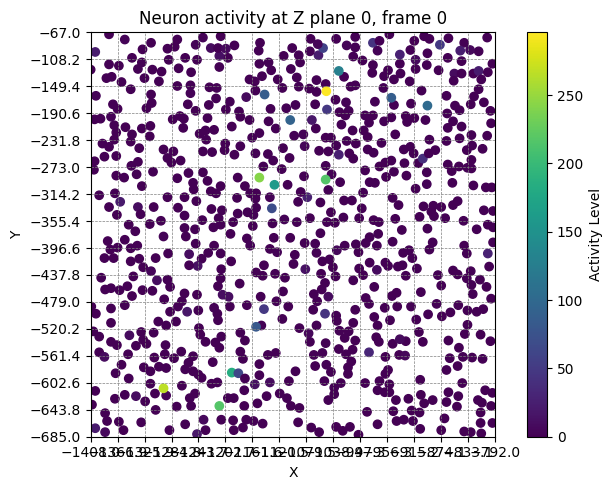

In [13]:
ax  = grid.plot_scatter_neurons_activity(axis=2, plane_idx=0, frame=0, positions=positions, activities=activities)

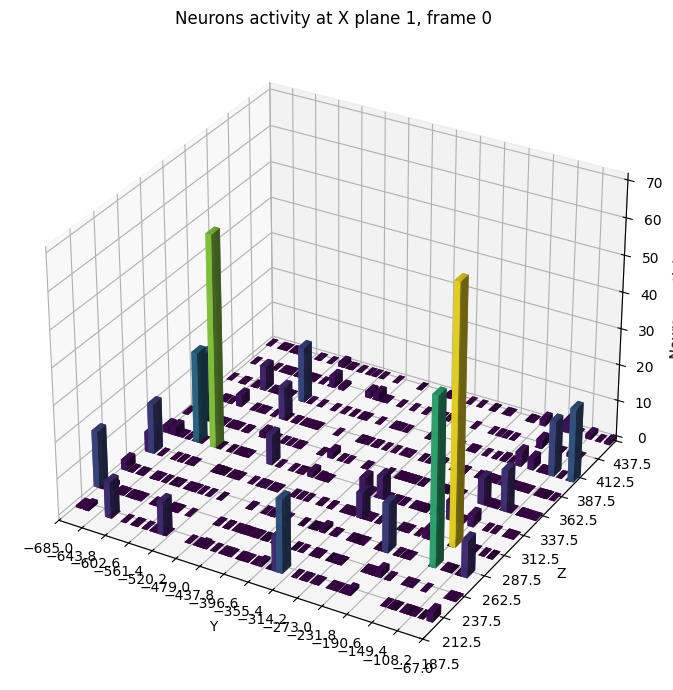

<Axes3D: title={'center': 'Neurons activity at X plane 1, frame 0'}, xlabel='Y', ylabel='Z', zlabel='Neurons activity'>

In [15]:
grid.plot_bar_neurons_activity(axis=0, plane_idx=1, frame=0, positions=positions, activities=activities)

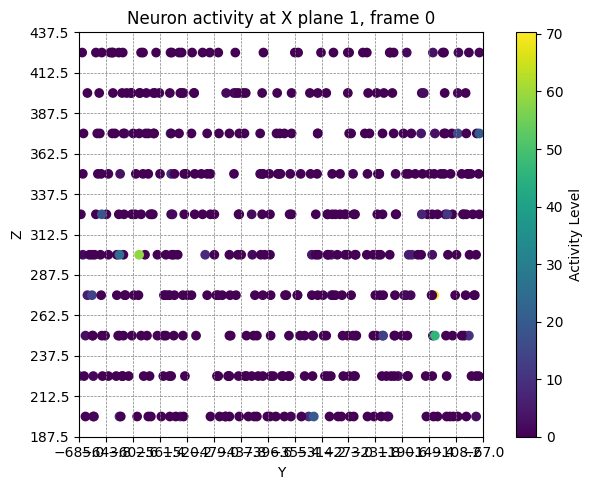

In [14]:
ax  = grid.plot_scatter_neurons_activity(axis=0, plane_idx=1, frame=0, positions=positions, activities=activities)

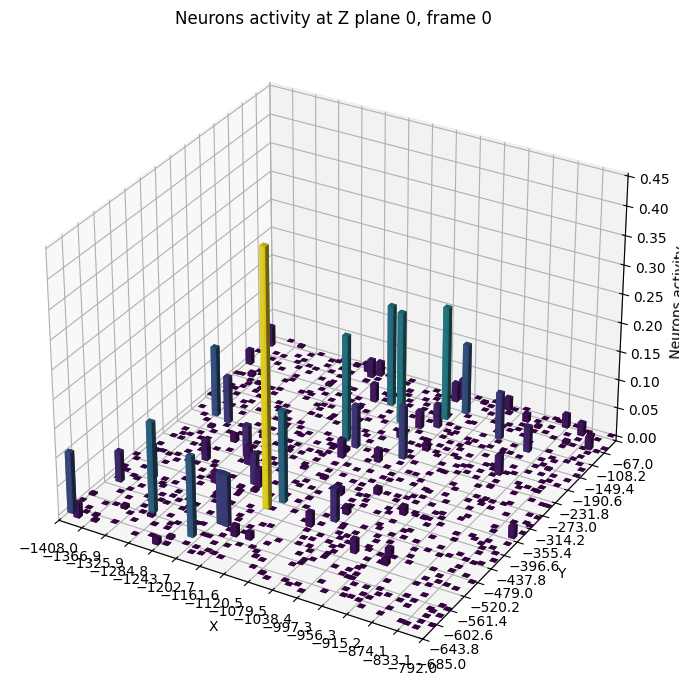

<Axes3D: title={'center': 'Neurons activity at Z plane 0, frame 0'}, xlabel='X', ylabel='Y', zlabel='Neurons activity'>

In [10]:
grid.plot_bar_neurons_activity(axis=2, plane_idx=0, frame=0, positions=positions,activities=activities_minmax)

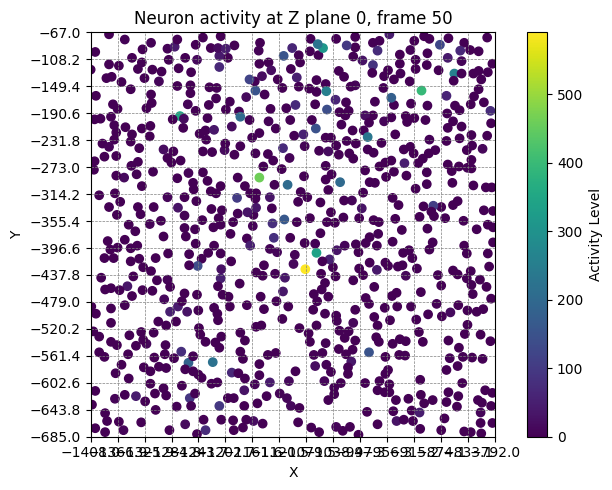

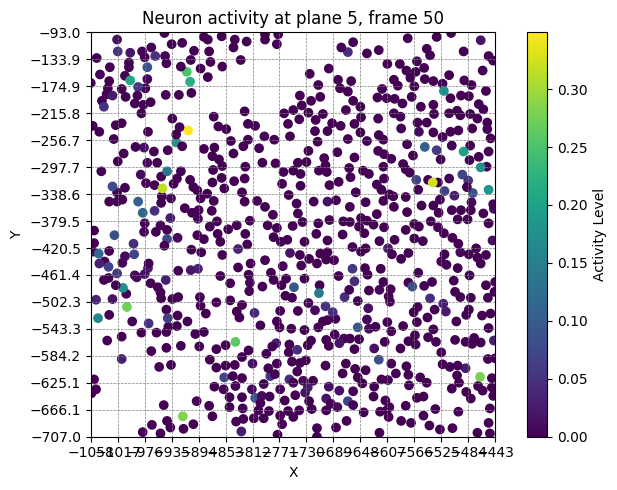

In [11]:
ax  = grid.plot_scatter_neurons_activity(plane=5, frame=50, positions=positions,activities=activities_minmax)


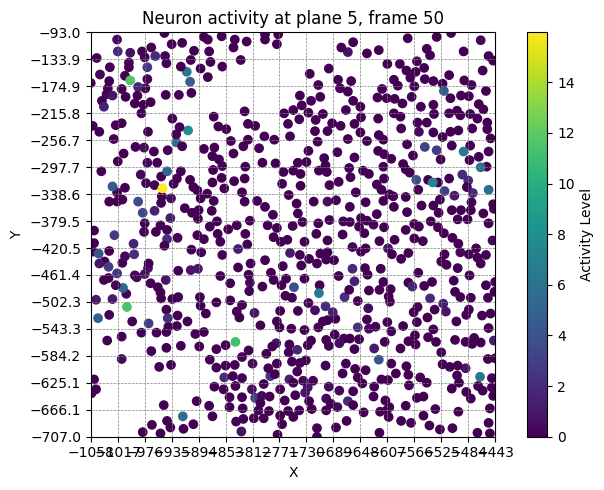

In [12]:
ax  = grid.plot_scatter_neurons_activity(plane=5, frame=50, positions=positions, activities=activities_std)


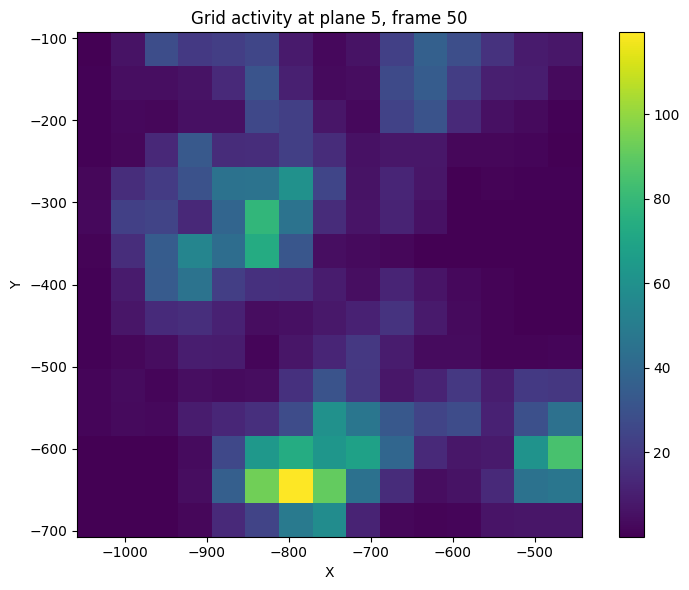

In [13]:
ax = grid.plot_colormesh_grid_activity(plane=5, frame=50, grid_activity=grid_activity)

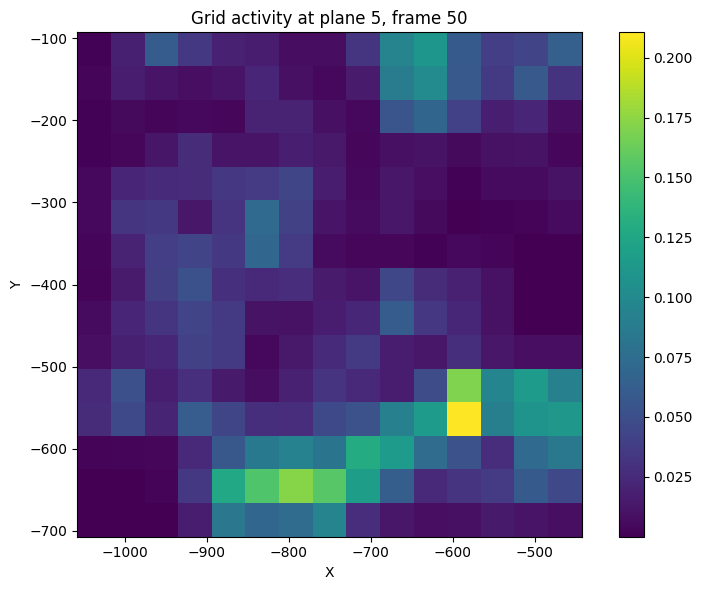

In [14]:
ax = grid.plot_colormesh_grid_activity(plane=5, frame=50, grid_activity=grid_activity_minmax)

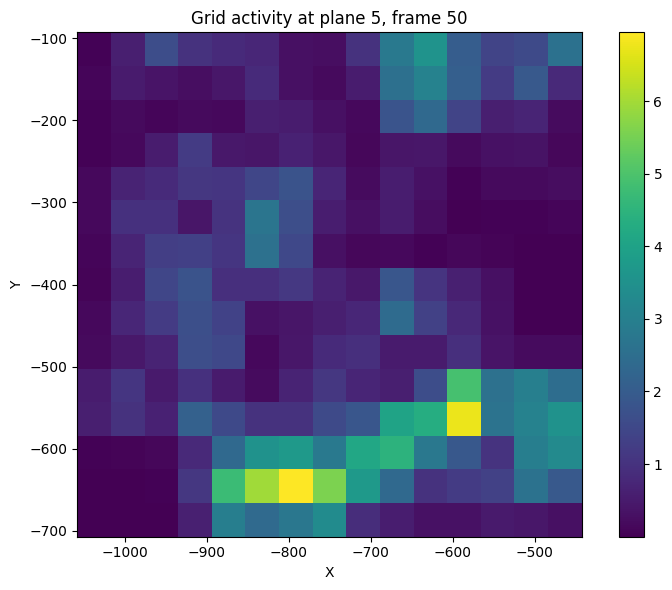

In [15]:
ax = grid.plot_colormesh_grid_activity(plane=5, frame=50, grid_activity=grid_activity_std)

In [16]:
grid_act_mean = np.mean(grid_activity, axis=-1)
grid_act_minmax_mean = np.mean(grid_activity_minmax, axis=-1)
grid_act_std_mean = np.mean(grid_activity_std, axis=-1)

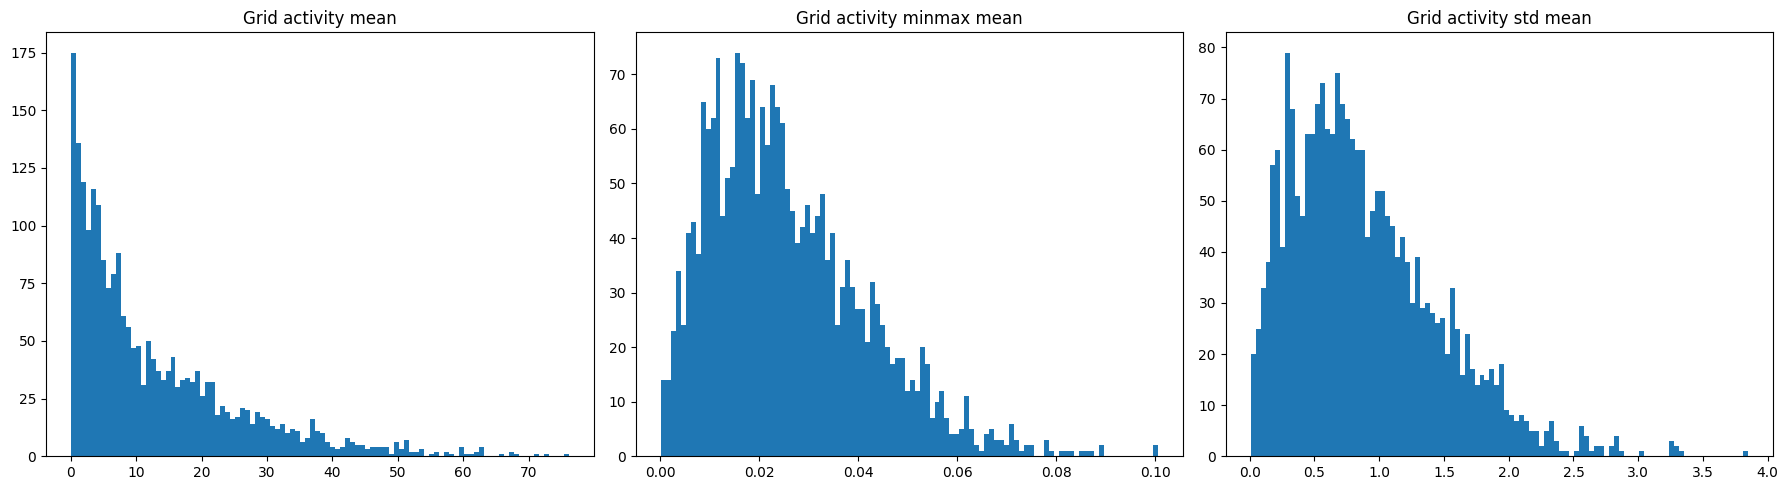

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
_ = ax[0].hist(grid_act_mean.flatten(), bins=100)
ax[0].set_title('Grid activity mean')
_ = ax[1].hist(grid_act_minmax_mean.flatten(), bins=100)
ax[1].set_title('Grid activity minmax mean')
_ = ax[2].hist(grid_act_std_mean.flatten(), bins=100)
ax[2].set_title('Grid activity std mean')
plt.tight_layout()

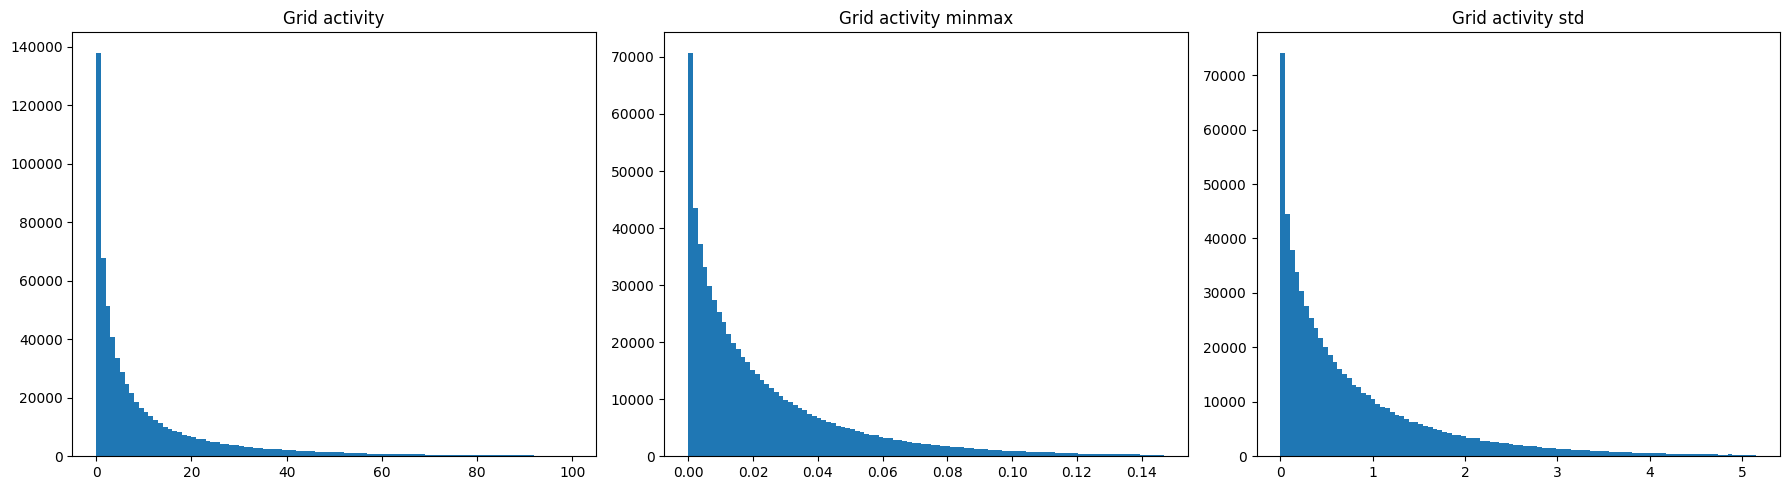

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
_ = ax[0].hist(grid_activity.flatten(), bins=100, range=(0, np.percentile(grid_activity.flatten(), 99)))
ax[0].set_title('Grid activity')
_ = ax[1].hist(grid_activity_minmax.flatten(), bins=100, range=(0, np.percentile(grid_activity_minmax.flatten(), 99)))
ax[1].set_title('Grid activity minmax')
_ = ax[2].hist(grid_activity_std.flatten(), bins=100, range=(0, np.percentile(grid_activity_std.flatten(), 99)))
ax[2].set_title('Grid activity std')
plt.tight_layout()

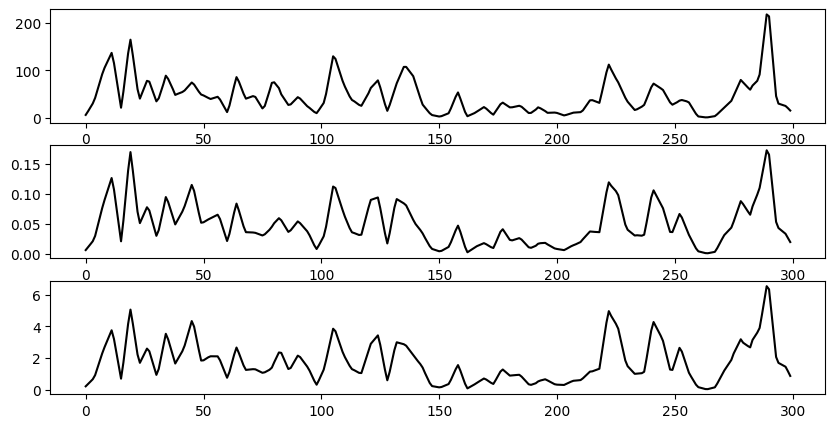

In [19]:
ix,iy,iz = 3,8,5

fig, ax = plt.subplots(3, 1, figsize=(10, 5))
ax[0].plot(grid_activity[ix,iy,iz,:],'k')
ax[1].plot(grid_activity_minmax[ix,iy,iz,:],'k')
ax[2].plot(grid_activity_std[ix,iy,iz,:],'k')
